In [11]:
import time
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Core imports
import pandas as pd
import numpy as np

# Sklearn imports
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Project-specific utilities
import sys
sys.path.append('..')
from HW_2_3.process_bank_churn import preprocess_data, create_preprocessor, preprocess_new_data
from HW_2_3.custom_features import get_custom_pipelines
from HW_2_3.plot_utils import plot_roc_curve, print_main_metrics, plot_feature_importances, plot_custom_confusion_matrix

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [2]:
raw_df = pd.read_csv('../assets/hw_2_2/train.csv')

raw_df.nunique()

numeric_cols = ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure']
categorical_cols = ['Geography', 'Gender', 'NumOfProducts']
target_enc_cols = ['NumOfProducts', 'Gender', 'Geography']

custom_pipelines = get_custom_pipelines()

preprocessor = create_preprocessor(numeric_cols, categorical_cols, target_enc_cols, custom_pipelines)

X_train, y_train, X_val, y_val, input_cols = preprocess_data(raw_df,
    preprocessor,
    "Exited",
    ["id", "CustomerId", "Surname", "Exited"]
)

print(X_train.head())
print(y_train.head())
print(input_cols)

       CreditScore    Balance  EstimatedSalary  Tenure  Geography_France  \
8263         696.0  130627.66         86786.41     5.0               1.0   
14199        632.0  119825.75        177737.04     4.0               0.0   
1856         679.0       0.00        162599.54     4.0               1.0   
3013         705.0       0.00        119814.25     3.0               1.0   
8266         696.0       0.00        100423.88     7.0               1.0   

       Geography_Germany  Geography_Spain  Gender_Male  NumOfProducts_1.0  \
8263                 0.0              0.0          1.0                1.0   
14199                1.0              0.0          0.0                1.0   
1856                 0.0              0.0          0.0                0.0   
3013                 0.0              0.0          1.0                0.0   
8266                 0.0              0.0          0.0                0.0   

       NumOfProducts_2.0  NumOfProducts_3.0  NumOfProducts_4.0  NumOfProducts  \

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

📊 Train metrics:
 AUROC: 0.818
 F1 score: 0.343

📊 Validation metrics:
 AUROC: 0.573
 F1 score: 0.186


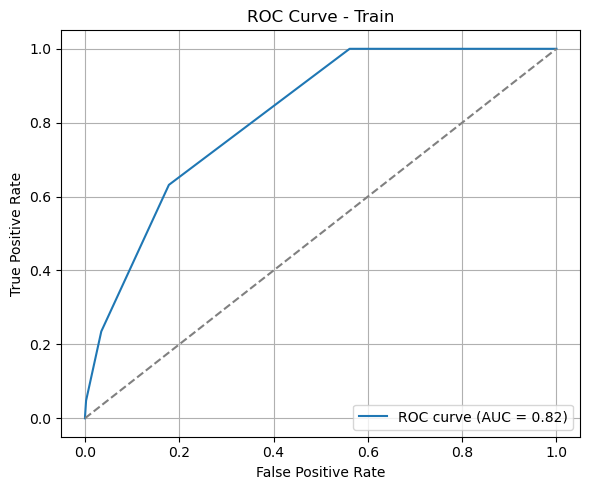

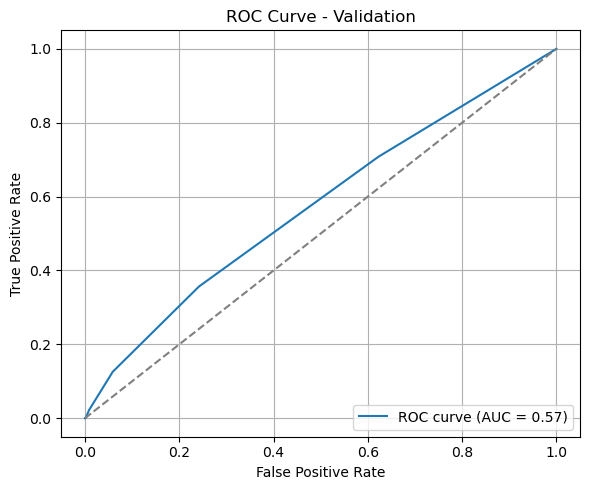

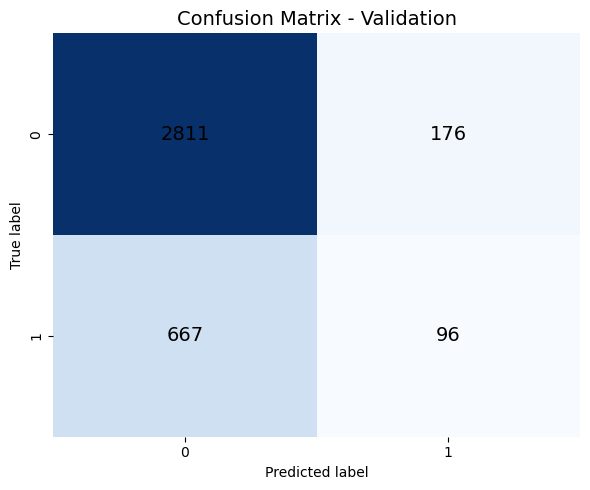

In [3]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_train_proba = knn.predict_proba(X_train)[:, 1]
y_val_proba = knn.predict_proba(X_val)[:, 1]

y_train_pred = knn.predict(X_train)
y_val_pred = knn.predict(X_val)

print("📊 Train metrics:")
train_metrics = print_main_metrics(y_train, y_train_proba, y_train_pred)

print("\n📊 Validation metrics:")
val_metrics = print_main_metrics(y_val, y_val_proba, y_val_pred)

plot_roc_curve(y_train, y_train_proba, title="ROC Curve - Train")
plot_roc_curve(y_val, y_val_proba, title="ROC Curve - Validation")

plot_custom_confusion_matrix(y_val, y_val_pred, title="Confusion Matrix - Validation")

### Summary

A k-Nearest Neighbors (kNN) classifier with default parameters was trained and evaluated using AUROC and F1 metrics on both training and validation datasets.

#### Performance:

| Metric         | Train Set | Validation Set |
|----------------|-----------|----------------|
| AUROC          | 0.818     | 0.573          |
| F1 Score       | 0.343     | 0.186          |

#### Interpretation:

- The model demonstrates acceptable performance on the training set but fails to generalize adequately to the validation data.
- The drop in AUROC from ~0.82 (train) to ~0.57 (validation) indicates poor generalization capability and suggests overfitting.
- The F1 score on validation is also very low (0.186), confirming limited practical use in identifying true positives.
- The confusion matrix shows a significant number of false negatives, meaning many churners remain undetected.
- Subjectively, the model's behavior feels similar to a person guessing without relevant knowledge — much like a blonde unaware that dinosaurs are extinct, who assumes there's a 50/50 chance of meeting one. That is, the model classifies cases **almost at random**.

#### Model conclusion:

The model is not good in its current form. It demonstrates clear signs of **high variance**: it fits well to the training data but fails to generalize to unseen data. This is typical for kNN models when using default settings in a feature-rich dataset without parameter tuning.


2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [4]:
param_grid = {'n_neighbors': list(range(2, 32))}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best n_neighbors: {grid_search.best_params_['n_neighbors']}")
knn_best = grid_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best n_neighbors: 28


📊 Train metrics (knn_best):
 AUROC: 0.678
 F1 score: 0.016

📊 Validation metrics (knn_best):
 AUROC: 0.614
 F1 score: 0.015


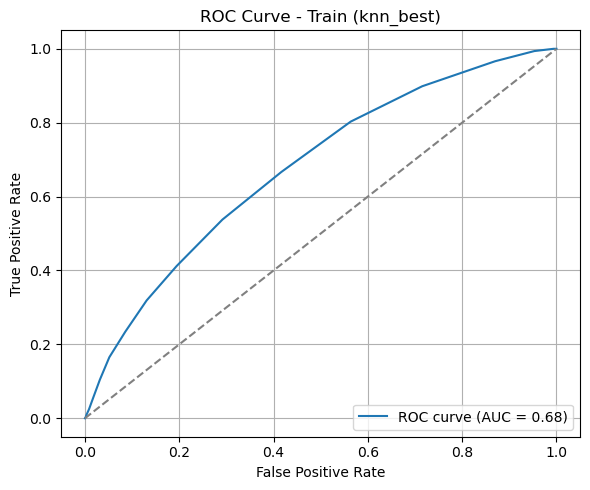

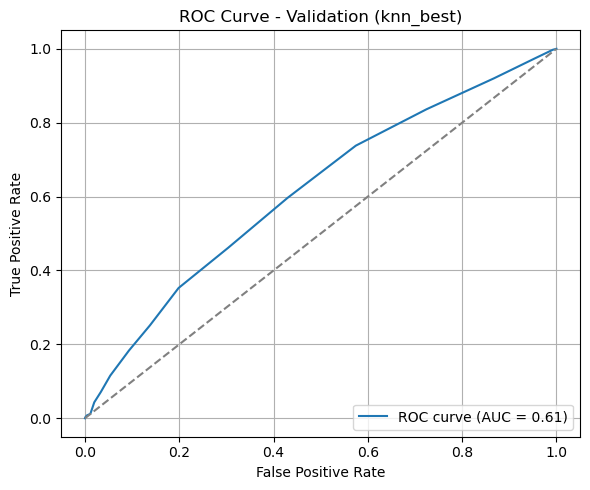

In [5]:
y_train_proba = knn_best.predict_proba(X_train)[:, 1]
y_val_proba = knn_best.predict_proba(X_val)[:, 1]

y_train_pred = knn_best.predict(X_train)
y_val_pred = knn_best.predict(X_val)

print("📊 Train metrics (knn_best):")
train_metrics = print_main_metrics(y_train, y_train_proba, y_train_pred)

print("\n📊 Validation metrics (knn_best):")
val_metrics = print_main_metrics(y_val, y_val_proba, y_val_pred)

# ROC
plot_roc_curve(y_train, y_train_proba, title="ROC Curve - Train (knn_best)")
plot_roc_curve(y_val, y_val_proba, title="ROC Curve - Validation (knn_best)")

### Summary

**Model**: `KNeighborsClassifier`
**Tuned parameter**: `n_neighbors` from 2 to 31
**Best value found**: `n_neighbors = 28`

#### Performance metrics:

| Dataset      | AUROC | F1-score |
|--------------|--------|-----------|
| Train        | 0.678  | 0.016     |
| Validation   | 0.614  | 0.015     |

---

### Interpretation

- After tuning `n_neighbors`, the model shows a **moderate improvement in AUROC** compared to the untuned version:
  - Validation AUROC improved from **0.573 → 0.614**
  - Training AUROC decreased from **0.818 → 0.678**, indicating reduced overfitting.
- **F1-score remains near zero**, meaning the classifier is **still unable to identify the positive class effectively**, likely predicting almost exclusively the majority class.

---

### Comparison with the previous model (`k=5`):

| Metric       | Untuned `k=5` | Tuned `k=28` |
|--------------|---------------|--------------|
| Train AUROC  | 0.818         | 0.678        |
| Val AUROC    | 0.573         | 0.614        |
| F1 (Val)     | 0.186         | 0.015        |

- While **AUROC improved**, **F1-score dropped drastically**, indicating that the model sacrifices recall completely.
- This is a **common issue for kNN with large `k` values**, especially in **imbalanced datasets**, where predictions are biased toward the dominant class.

---

### Conclusion

The tuned `kNN` model exhibits characteristics of **high bias and low variance**.
It slightly improves generalization (AUROC) but fails at identifying minority class instances (F1 ≈ 0).

> Statistically speaking — model is not wrong, but practically useless.

Thus, `kNN` may not be suitable for this task without:
- Addressing class imbalance,
- Using other classifiers better suited for high-dimensional or imbalanced data (e.g., tree-based models),
- Applying dimensionality reduction or threshold tuning.


3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

Fitting 3 folds for each of 90 candidates, totalling 270 fits
⏱ GridSearch time: 0.50 seconds
Best parameters: {'max_depth': 5, 'max_leaf_nodes': 10}
Train AUROC: 0.900
Validation AUROC: 0.902


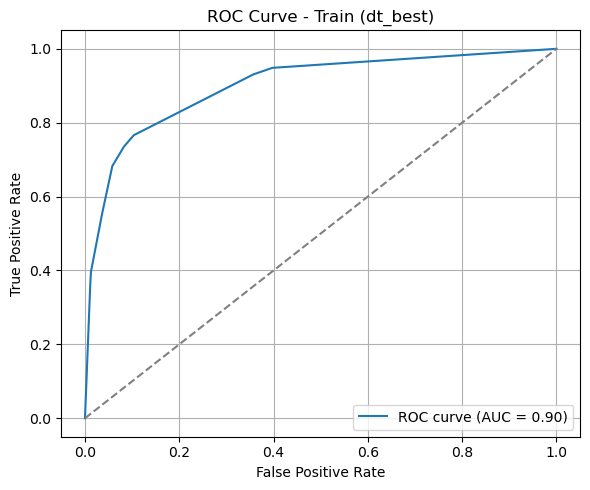

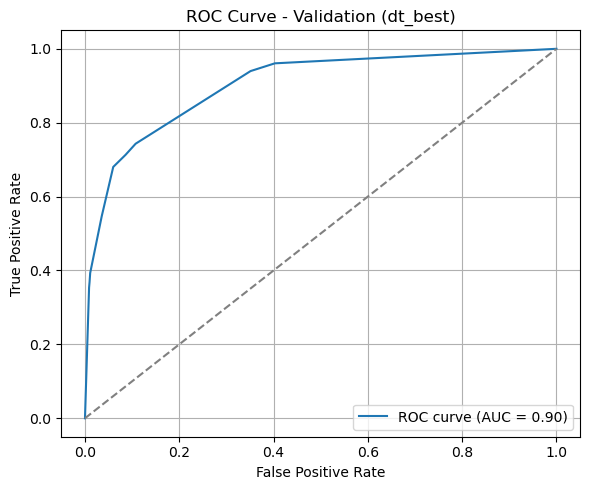

In [8]:
param_grid = {
    'max_depth': list(range(1, 21, 2)),
    'max_leaf_nodes': list(range(2, 11))
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

print(f"⏱ GridSearch time: {end_time - start_time:.2f} seconds")

print("Best parameters:", grid_search.best_params_)

dt_best = grid_search.best_estimator_

y_train_pred_proba = dt_best.predict_proba(X_train)[:, 1]
y_val_pred_proba = dt_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"Train AUROC: {train_auc:.3f}")
print(f"Validation AUROC: {val_auc:.3f}")

plot_roc_curve(y_train, y_train_pred_proba, title="ROC Curve - Train (dt_best)")
plot_roc_curve(y_val, y_val_pred_proba, title="ROC Curve - Validation (dt_best)")

### Summary

**Search configuration:**
- **Model:** `DecisionTreeClassifier(random_state=42)`
- **Parameter grid:**
  - `max_depth`: from 1 to 20 (step = 2)
  - `max_leaf_nodes`: from 2 to 10 (step = 1)
- **Cross-validation:** 3-fold
- **Scoring:** ROC AUC
- **Search time:** ~0.50 seconds
- **Total grid size:** 10 × 9 = 90 combinations

---

### Best hyperparameters:
```python
{'max_depth': 5, 'max_leaf_nodes': 10}
```

---

### Performance

| Dataset      | AUROC |
|--------------|--------|
| Train        | 0.900  |
| Validation   | 0.902  |

---

### Interpretation

- The model shows **nearly perfect generalization**, with AUROC scores on the train and validation sets being almost equal.
- This indicates that the decision tree is **neither overfitting nor underfitting** — a sign of **low variance** and **low bias**.
- In contrast to all previous kNN models (even after tuning), this tree performs **substantially better** and consistently.
- The tree structure is shallow and simple (depth = 5, 10 leaf nodes), suggesting that key patterns in the data are efficiently captured without unnecessary complexity.

---

### Conclusion

- The tuned `DecisionTreeClassifier` is **clearly superior** to previous models (including manually and automatically tuned kNN).
- It can confidently serve as a **baseline** or become part of more advanced ensembles (Random Forests, Gradient Boosting, etc.).


4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

Fitting 3 folds for each of 40 candidates, totalling 120 fits
⏱ RandomizedSearch completed in 0.27 seconds
🔧 Best parameters: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': 14, 'max_features': None, 'max_depth': 16, 'criterion': 'entropy'}
Train AUROC: 0.900
Validation AUROC: 0.902


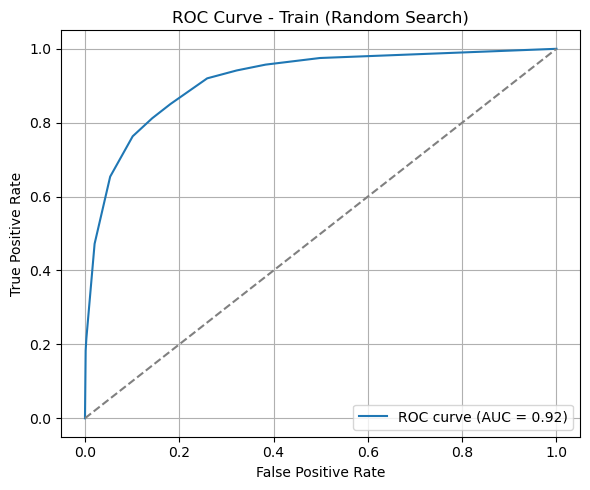

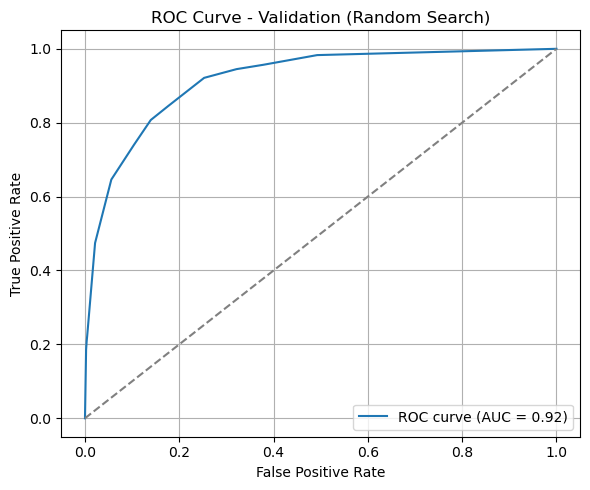

In [13]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dt = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dt,
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()
random_search.fit(X_train, y_train)
elapsed_time = time.time() - start_time

dt_random_search_best = random_search.best_estimator_
print(f"⏱ RandomizedSearch completed in {elapsed_time:.2f} seconds")
print("🔧 Best parameters:", random_search.best_params_)

y_train_pred = dt_random_search_best.predict(X_train)
y_train_proba = dt_random_search_best.predict_proba(X_train)[:, 1]
y_val_pred = dt_random_search_best.predict(X_val)
y_val_proba = dt_random_search_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"Train AUROC: {train_auc:.3f}")
print(f"Validation AUROC: {val_auc:.3f}")

plot_roc_curve(y_train, y_train_proba, title="ROC Curve - Train (Random Search)")
plot_roc_curve(y_val, y_val_proba, title="ROC Curve - Validation (Random Search)")

# Summary

## Model Configurations and Results

### Grid Search (`GridSearchCV`)

**Best Parameters**:
- `max_depth`: 5
- `max_leaf_nodes`: 10

**Performance**:
- **Train AUROC**: 0.900
- **Validation AUROC**: 0.902
- **Kaggle Public Score**: `0.81642`
- **Grid Search Time**: ~0.50s

---

### Random Search (`RandomizedSearchCV`)

**Best Parameters**:
- `splitter`: best
- `min_samples_split`: 20
- `min_samples_leaf`: 2
- `max_leaf_nodes`: 14
- `max_features`: None
- `max_depth`: 16
- `criterion`: entropy

**Performance**:
- **Train AUROC**: 0.900
- **Validation AUROC**: 0.902
- **Kaggle Public Score**: `0.82718`
- **Randomized Search Time**: ~0.27s

---

### Manually Tuned Soft Parameters

**Parameters**:
- `max_depth`: 8
- `max_leaf_nodes`: 44

**Kaggle Public Score**: `0.82029`

---

### Untuned Default Tree

No explicit parameter tuning.

**Kaggle Public Score**: `0.80814`

---

## Kaggle Submission Comparison

| Model                                 | Public Score |
|---------------------------------------|--------------|
| `submission_tree_full_randomsearch`   | **0.82718**  |
| `submission_tree_full_gridsearch`     | 0.81642      |
| `submission_tree_full_train_depth8`   | 0.82029      |
| `submission_soft_params_tree_depth6`  | 0.80566      |
| `submission_decision_tree`            | 0.80814      |

---

## Interpretation & Conclusion

- Both `GridSearchCV` and `RandomizedSearchCV` achieved similarly high AUROC on train and validation (~0.90).
- Despite identical AUROC, `RandomizedSearchCV` found a slightly **better Kaggle score**, suggesting **regularization helped generalization**.
- The tuned models **outperform manually defined or default parameters**, validating the need for hyperparameter optimization.
- Random search allowed for **exploration of more diverse parameters**, such as `min_samples_split` and `criterion`, giving a slight edge.

---


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [17]:
test_raw_df = pd.read_csv("../assets/hw_2_2/test.csv")
submission_df = pd.read_csv("../assets/hw_2_2/sample_submission.csv")

drop_cols = ["id", "CustomerId", "Surname", "Exited"]
input_cols_all = [col for col in raw_df.columns if col not in drop_cols]

X_all = raw_df[input_cols_all]
y_all = raw_df["Exited"]
X_all_processed = preprocessor.transform(X_all)

X_test_processed = preprocess_new_data(test_raw_df, preprocessor)

# ====== GridSearch ======
tree_grid = DecisionTreeClassifier(
    max_depth=5,
    max_leaf_nodes=10,
    random_state=42
)
tree_grid.fit(X_all_processed, y_all)

preds_grid = tree_grid.predict(X_test_processed)

submission_df_grid = submission_df.copy()
submission_df_grid["Exited"] = preds_grid
submission_df_grid.to_csv("../assets/hw_2_4/submission_tree_full_gridsearch.csv", index=False)

# ====== RandomizedSearch ======
tree_random = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=16,
    max_leaf_nodes=14,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features=None,
    random_state=42
)
tree_random.fit(X_all_processed, y_all)

preds_random = tree_random.predict(X_test_processed)

submission_df_random = submission_df.copy()
submission_df_random["Exited"] = preds_random
submission_df_random.to_csv("../assets/hw_2_4/submission_tree_full_randomsearch.csv", index=False)

display(submission_df_grid.head())
display(submission_df_random.head())


C:\Users\Dmity\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Dmity\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


,id,Exited
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,1.0
4,15004,0.0


,id,Exited
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,1.0
4,15004,0.0
